In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
# This helps to run on GPU device 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
data = pd.read_csv("/Users/sushil0711/Downloads/Tesla.csv - Tesla.csv.csv", 
                     index_col=0, parse_dates=True)
data.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [4]:
data.shape

(1692, 6)

In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1692 entries, 2010-06-29 to 2017-03-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1692 non-null   float64
 1   High       1692 non-null   float64
 2   Low        1692 non-null   float64
 3   Close      1692 non-null   float64
 4   Volume     1692 non-null   int64  
 5   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 92.5 KB


In [6]:
data.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [7]:
data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [8]:
data.drop(["Adj Close"], axis = 1, inplace = True)

In [9]:
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900


In [10]:
X = data.drop(["Close"], axis = 1).values
y = data["Close"].values

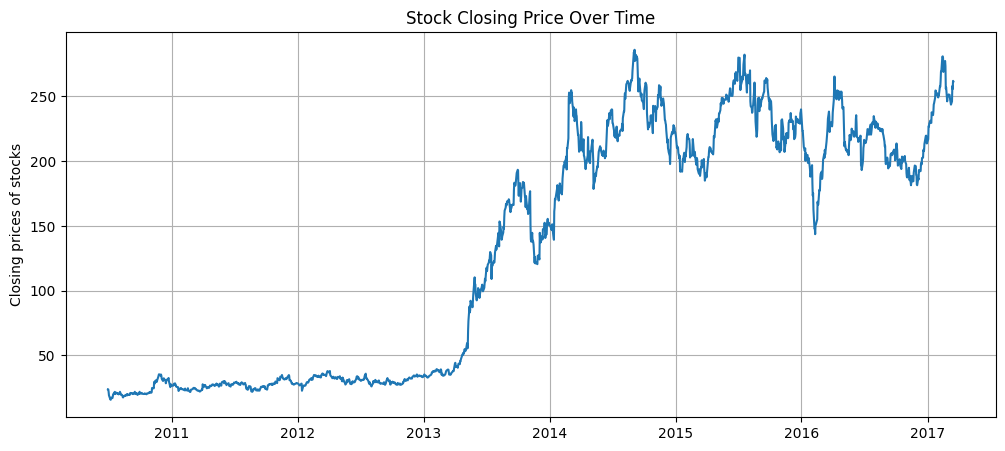

In [11]:
plt.figure(figsize=(12,5))
plt.title('Stock Closing Price Over Time')
plt.ylabel('Closing prices of stocks')
plt.grid(True)
plt.plot(data['Close'])
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [13]:
from sklearn.preprocessing import MinMaxScaler
X_scaler = MinMaxScaler(feature_range = (-1,1))
y_scaler = MinMaxScaler(feature_range = (-1,1))
X_train = X_scaler.fit_transform(X_train)
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
X_test = X_scaler.transform(X_test)
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()

In [14]:
def createSeq(X, y, ws):
    x_seq = []
    y_seq = [] 

    for i in range(len(X) - ws - 1):
        x_seq.append(X[i : i + ws])
        y_seq.append(y[i + ws])

    return x_seq, y_seq



window_size = 60 
X_train_seq, y_train_seq = createSeq(X_train, y_train, window_size)


In [15]:
X_train = torch.FloatTensor(X_train_seq)
y_train = torch.FloatTensor(y_train_seq)

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_33478/1210332201.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X_train = torch.FloatTensor(X_train_seq)


In [16]:
train_data = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_data, 
    batch_size = 32, 
    shuffle=True
)

In [17]:
class LSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz, out_sz):
        super().__init__()

        self.hidden_sz = hidden_sz

        self.lstm = nn.LSTM(input_sz, hidden_sz, batch_first = True)
        self.linear = nn.Linear(hidden_sz, out_sz)

    def forward(self, seq):

        h0 = torch.zeros(1,seq.size(0), self.hidden_sz, device = device)
        c0 = torch.zeros(1,seq.size(0), self.hidden_sz, device = device) 

        lstm_out, _ = self.lstm(seq, (h0, c0))

        pred = self.linear(lstm_out[:, -1, :])

        return pred 

In [18]:
torch.manual_seed(101)
model = LSTM(4, 128, 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
model

LSTM(
  (lstm): LSTM(4, 128, batch_first=True)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)

In [19]:
# Train the Model  
epochs = 100 

import time
start_time = time.time()

for epoch in range(epochs):

    model.train()

    for seq, y_train in train_loader:

        seq = seq.to(device)
        y_train = y_train.to(device)

        optimizer.zero_grad()
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train.unsqueeze(1))
        loss.backward()
        optimizer.step()

    
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

        

Epoch:  1 Loss: 0.00372871
Epoch:  2 Loss: 0.00091061
Epoch:  3 Loss: 0.00169526
Epoch:  4 Loss: 0.00241586
Epoch:  5 Loss: 0.00067063
Epoch:  6 Loss: 0.00344766
Epoch:  7 Loss: 0.00648648
Epoch:  8 Loss: 0.00402608
Epoch:  9 Loss: 0.00056533
Epoch: 10 Loss: 0.00413998
Epoch: 11 Loss: 0.00219248
Epoch: 12 Loss: 0.00203258
Epoch: 13 Loss: 0.00142129
Epoch: 14 Loss: 0.00161309
Epoch: 15 Loss: 0.00539243
Epoch: 16 Loss: 0.00278012
Epoch: 17 Loss: 0.00181029
Epoch: 18 Loss: 0.00133426
Epoch: 19 Loss: 0.00113844
Epoch: 20 Loss: 0.00466382
Epoch: 21 Loss: 0.00039454
Epoch: 22 Loss: 0.00091704
Epoch: 23 Loss: 0.00094551
Epoch: 24 Loss: 0.00088982
Epoch: 25 Loss: 0.00257276
Epoch: 26 Loss: 0.00147847
Epoch: 27 Loss: 0.00156462
Epoch: 28 Loss: 0.00251491
Epoch: 29 Loss: 0.00135902
Epoch: 30 Loss: 0.00062474
Epoch: 31 Loss: 0.00283206
Epoch: 32 Loss: 0.00148555
Epoch: 33 Loss: 0.00225572
Epoch: 34 Loss: 0.00220234
Epoch: 35 Loss: 0.00106778
Epoch: 36 Loss: 0.00121268
Epoch: 37 Loss: 0.00009945
E

In [20]:
X_test_seq, y_test_seq = createSeq(X_test, y_test, window_size)

X_test_seq = torch.FloatTensor(X_test_seq)
y_test_seq = torch.FloatTensor(y_test_seq)

In [21]:
# Test Evaluation

model.eval()

test_preds = []

with torch.no_grad():

    for seq in X_test_seq:

        seq = seq.unsqueeze(0).to(device)

        y_pred = model(seq)

        test_preds.append(y_pred.item())

In [22]:
test_preds

[0.03125844523310661,
 0.013009920716285706,
 0.00635547935962677,
 0.04855626821517944,
 0.012447964400053024,
 0.07896506041288376,
 0.10120658576488495,
 0.14773841202259064,
 0.10535897314548492,
 0.17816591262817383,
 0.19502148032188416,
 0.16511663794517517,
 0.23811250925064087,
 0.2891063094139099,
 0.31899645924568176,
 0.2966097295284271,
 0.25638338923454285,
 0.3108232617378235,
 0.38352563977241516,
 0.3880941867828369,
 0.4037584662437439,
 0.41264018416404724,
 0.42551127076148987,
 0.42234858870506287,
 0.47628673911094666,
 0.4785110056400299,
 0.5154260993003845,
 0.5428886413574219,
 0.5962837934494019,
 0.6372866630554199,
 0.621182382106781,
 0.5711455941200256,
 0.5178205370903015,
 0.6044125556945801,
 0.5854998230934143,
 0.6070231199264526,
 0.5924217104911804,
 0.6691474318504333,
 0.7112157344818115,
 0.7086981534957886,
 0.8126583099365234,
 0.8151533007621765,
 0.754591166973114,
 0.7315905690193176,
 0.6982751488685608,
 0.7341364026069641,
 0.74937981367

In [23]:
true_predictions = y_scaler.inverse_transform(np.array(test_preds).reshape(-1, 1))
actual = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
true_predictions

array([[155.14364576],
       [152.67790505],
       [151.7787569 ],
       [157.48092768],
       [152.60197351],
       [161.58976382],
       [164.59503882],
       [170.8824194 ],
       [165.15610943],
       [174.99378342],
       [177.2713078 ],
       [173.23056536],
       [183.09376782],
       [189.98405033],
       [194.02280751],
       [190.99791249],
       [185.56252921],
       [192.91844502],
       [202.74199067],
       [203.35929276],
       [205.47585028],
       [206.67594804],
       [208.41508932],
       [207.98774771],
       [215.27587083],
       [215.57641374],
       [220.56438136],
       [224.27512016],
       [231.48987335],
       [237.03018128],
       [234.85417077],
       [228.09319975],
       [220.8879178 ],
       [232.58823175],
       [230.03274323],
       [232.9409712 ],
       [230.96802869],
       [241.3352085 ],
       [247.01947774],
       [246.67930219],
       [260.726399  ],
       [261.06352217],
       [252.88036638],
       [249

In [24]:
results = pd.DataFrame({
    "Actual_data" : actual, 
    "prediction" : true_predictions.flatten() 
})
results

,Actual_data,prediction
0,148.250000,155.143646
1,143.669998,152.677905
2,150.470001,151.778757
3,151.039993,157.480928
4,155.169998,152.601974
...,...,...
273,243.690005,243.301990
274,246.169997,243.019665
275,258.000001,243.623690
276,255.729995,250.451564


In [25]:
model.eval()

train_preds = []
train_targets = []

with torch.no_grad():
    for seq, target in train_loader:

        seq = seq.to(device)
        target = target.to(device)

        y_pred = model(seq)

        train_preds.extend(y_pred.cpu().numpy().flatten())
        train_targets.extend(target.cpu().numpy().flatten())

In [26]:
train_preds = y_scaler.inverse_transform(
    np.array(train_preds).reshape(-1, 1)
)

train_targets = y_scaler.inverse_transform(
    np.array(train_targets).reshape(-1, 1) 
)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
train_mae = mean_absolute_error(train_targets, train_preds)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)

test_rmse = np.sqrt(mean_squared_error(actual, true_predictions))
test_mae = mean_absolute_error(actual, true_predictions)

print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)

Train RMSE: 4.597424963981302
Train MAE: 2.789581298828125
Test RMSE: 5.642795963454775
Test MAE: 4.263302557796214


In [28]:
results.index = data.index[-len(results):]

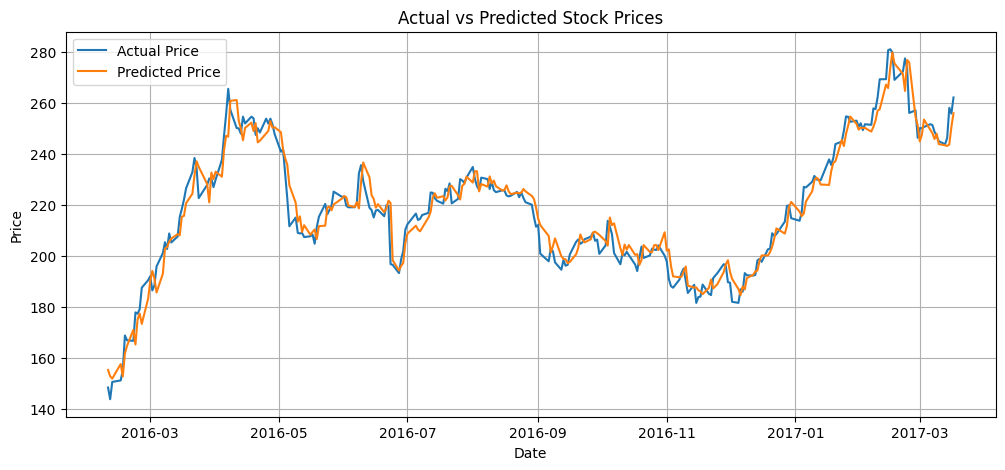

In [29]:
plt.figure(figsize=(12,5))

plt.plot(results.index, results["Actual_data"].values, label="Actual Price")
plt.plot(results.index, results["prediction"].values, label="Predicted Price")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)
plt.legend()
plt.show()